In [2]:
import numpy as np
import matplotlib.pyplot as plt

from skimage import data
from skimage import exposure

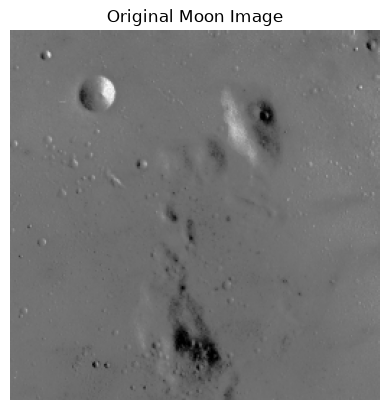

In [3]:
img = data.moon()

plt.imshow(img, cmap='gray')
plt.title('Original Moon Image')
plt.axis('off')
plt.show()

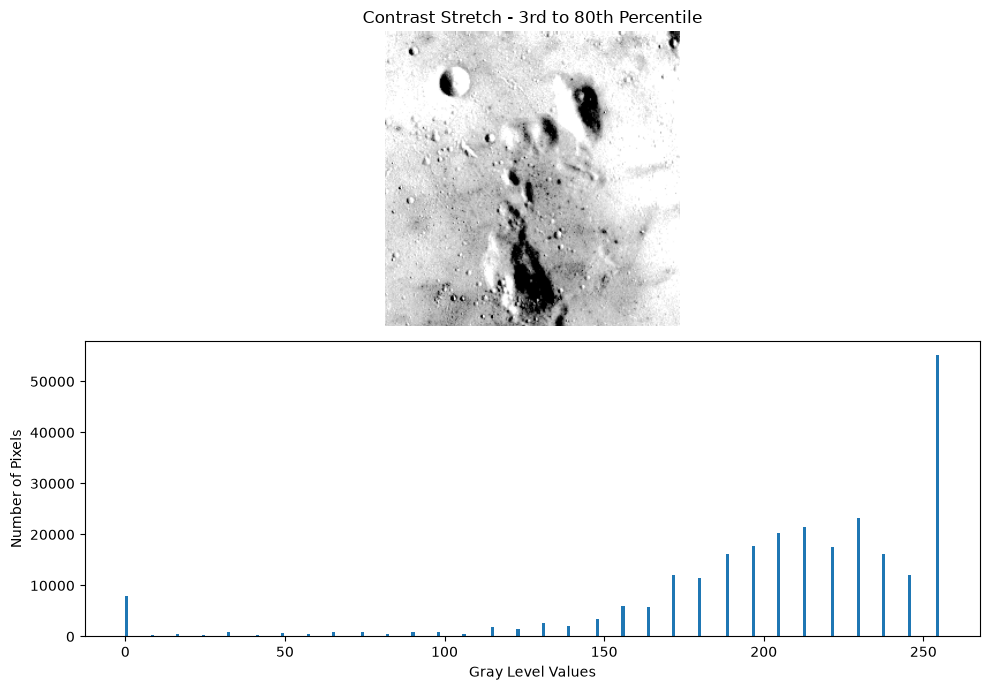

In [4]:
# Task 1

p3, p80 = np.percentile(img, (3, 80))

img_rescale = exposure.rescale_intensity(
    img,
    in_range=(p3, p80)
)

plt.figure(figsize=(10, 7))

plt.subplot(2, 1, 1)
plt.imshow(img_rescale, cmap='gray')
plt.title('Contrast Stretch - 3rd to 80th Percentile')
plt.axis('off')

plt.subplot(2, 1, 2)
plt.hist(
    img_rescale.flat,
    bins=256,
    range=(0, 255)
)

plt.xlabel('Gray Level Values')
plt.ylabel('Number of Pixels')

plt.tight_layout()
plt.show()

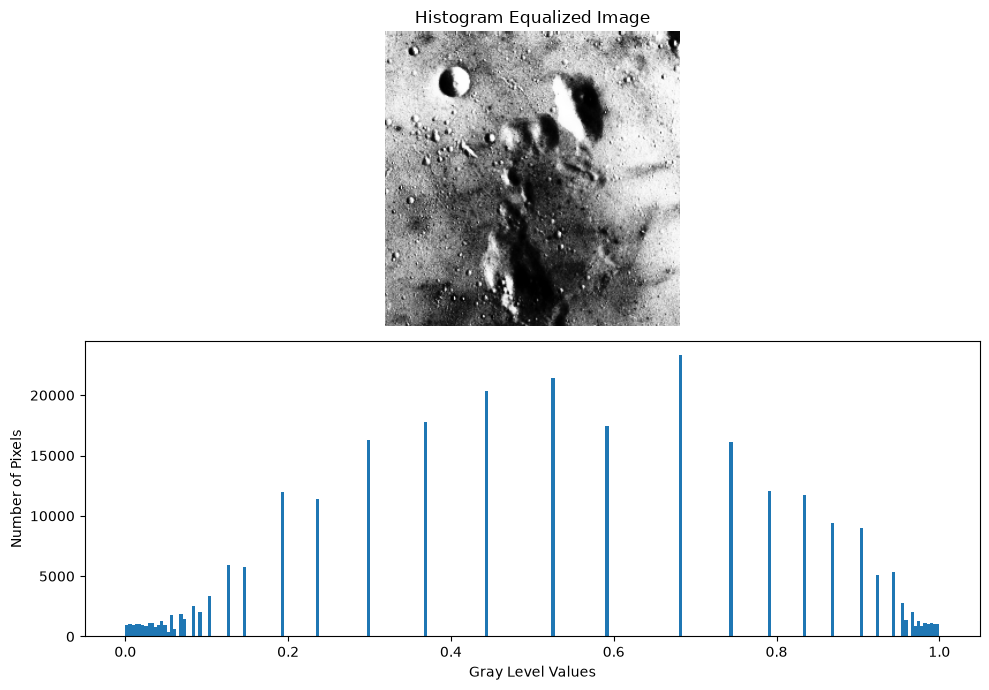

In [5]:
# Task 2

img_equalized = exposure.equalize_hist(img)

plt.figure(figsize=(10, 7))

plt.subplot(2, 1, 1)
plt.imshow(img_equalized, cmap='gray')
plt.title('Histogram Equalized Image')
plt.axis('off')

plt.subplot(2, 1, 2)
plt.hist(
    img_equalized.flat,
    bins=256,
    range=(0, 1)
)

plt.xlabel('Gray Level Values')
plt.ylabel('Number of Pixels')

plt.tight_layout()
plt.show()

In [7]:
# Task 3

chelsea = data.chelsea()
reference = data.rocket()

matched = exposure.match_histograms(
    chelsea,
    reference,
    channel_axis=-1
)

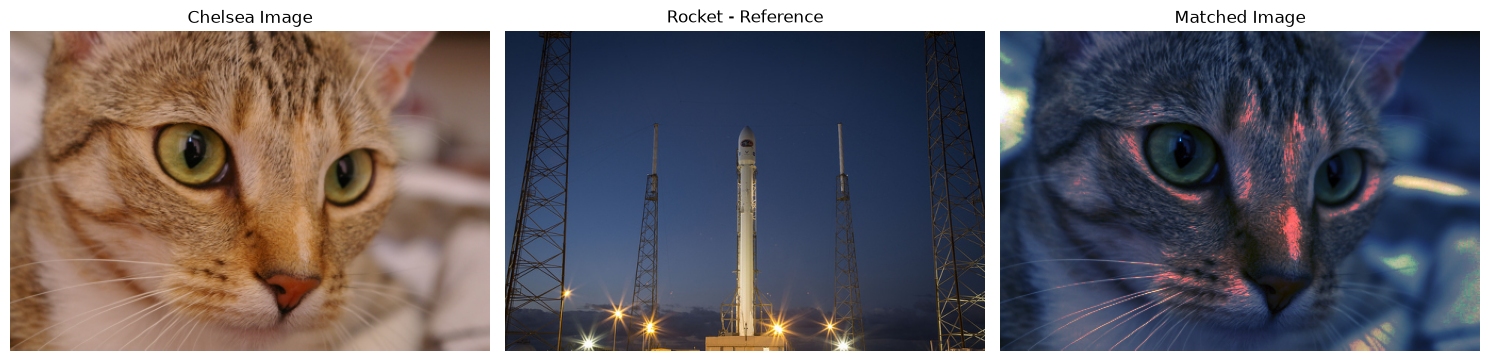

In [8]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(chelsea)
plt.title('Chelsea Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(reference)
plt.title('Rocket - Reference')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(matched)
plt.title('Matched Image')
plt.axis('off')

plt.tight_layout()
plt.show()

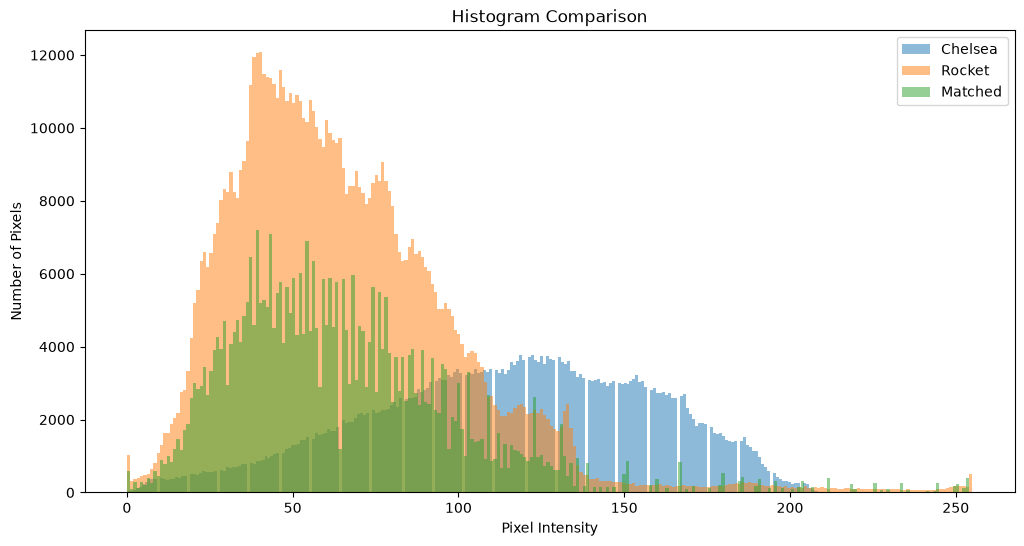

In [9]:
plt.figure(figsize=(12, 6))

plt.hist(
    chelsea.ravel(),
    bins=256,
    alpha=0.5,
    label='Chelsea'
)

plt.hist(
    reference.ravel(),
    bins=256,
    alpha=0.5,
    label='Rocket'
)

plt.hist(
    matched.ravel(),
    bins=256,
    alpha=0.5,
    label='Matched'
)

plt.xlabel('Pixel Intensity')
plt.ylabel('Number of Pixels')
plt.title('Histogram Comparison')
plt.legend()

plt.show()